In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 11: Testing the Filtered Detector Across Multiple Timepoints

**Objective:** Evaluate whether the Chapter 10 filtered detector generalizes across multiple timepoints from the same sample.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- train a candidate-ranking model on one timepoint
- apply the same model to multiple other timepoints
- compare filtered detector performance across time
- measure whether top-k filtering remains useful as the sample changes
- identify whether the detector is stable or overfit to a single frame

# 🧠 Background Theory

In Chapter 10, I turned a noisy LoG blob detector into a filtered detector by ranking candidates according to a GT-like score.

However, that detector was evaluated on only one frame. A useful detector must generalize beyond a single timepoint.

In this notebook, I will train the ranking model on one reference timepoint (`t = 8`) and then apply it to multiple other timepoints from the same sample to see whether the filtered detector remains effective.

# 🗺️ Chapter Roadmap

This notebook will proceed in six stages:

1. **Load the sample and helper functions**
2. **Train the ranking model on the reference timepoint (`t = 8`)**
3. **Run the filtered detector across multiple timepoints**
4. **Evaluate top-25 / top-50 / top-100 filtered candidate sets**
5. **Compare performance across time**
6. **Visualize one or two example timepoints**

# 📚 New Vocabulary

## Generalization
How well a model trained on one frame works on different frames.

## Reference Timepoint
The timepoint used to train the ranking model before testing it on other frames.

## Cross-Timepoint Evaluation
Evaluating the same detector pipeline across multiple timepoints in the same sample.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 82.4 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import blob_log
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [4]:
print("Imports successful.")

Imports successful.


# Step 1 — Load the Sample and Reuse the Detector Pipeline

I will reuse the same sample and the same detector-building utilities from Chapters 9 and 10.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

# Load image
volume = zarr.open(zarr_path, mode="r")
image = volume["0"]   # shape: (T, Z, Y, X)

# Load graph
geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

print("Image shape:", image.shape)
print("Total labeled nodes:", len(nodes_df))
nodes_df.head()

Image shape: (100, 64, 256, 256)
Total labeled nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


In [6]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)

In [7]:
def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    distances = np.sqrt(((gt - pred) ** 2).sum(axis=2))
    return distances

In [8]:
def evaluate_detector(gt_points, pred_points, match_radius=6):
    if len(pred_points) == 0:
        return {
            "num_gt": len(gt_points),
            "num_pred": 0,
            "gt_detected": 0,
            "gt_missed": len(gt_points),
            "pred_matched": 0,
            "pred_unmatched": 0,
            "gt_recall": 0.0,
            "pred_precision_like": np.nan,
            "min_dist_gt": np.full(len(gt_points), np.inf),
            "min_dist_pred": np.array([]),
            "gt_matched_mask": np.zeros(len(gt_points), dtype=bool),
            "pred_matched_mask": np.array([], dtype=bool),
        }

    dist = pairwise_distances_3d(gt_points, pred_points)

    min_dist_gt = dist.min(axis=1)
    min_dist_pred = dist.min(axis=0)

    gt_matched_mask = min_dist_gt <= match_radius
    pred_matched_mask = min_dist_pred <= match_radius

    gt_detected = gt_matched_mask.sum()
    gt_missed = len(gt_points) - gt_detected

    pred_matched = pred_matched_mask.sum()
    pred_unmatched = len(pred_points) - pred_matched

    return {
        "num_gt": len(gt_points),
        "num_pred": len(pred_points),
        "gt_detected": gt_detected,
        "gt_missed": gt_missed,
        "pred_matched": pred_matched,
        "pred_unmatched": pred_unmatched,
        "gt_recall": gt_detected / len(gt_points),
        "pred_precision_like": pred_matched / len(pred_points),
        "min_dist_gt": min_dist_gt,
        "min_dist_pred": min_dist_pred,
        "gt_matched_mask": gt_matched_mask,
        "pred_matched_mask": pred_matched_mask,
    }

In [9]:
def extract_candidate_features(frame_3d, detections_df, patch_radius=4):
    rows = []
    z_max, y_max, x_max = frame_3d.shape

    for _, row in detections_df.iterrows():
        z = int(row["z"])
        y = int(row["y"])
        x = int(row["x"])

        slice_2d = frame_3d[z].astype(np.float32)

        y0 = max(0, y - patch_radius)
        y1 = min(y_max, y + patch_radius + 1)
        x0 = max(0, x - patch_radius)
        x1 = min(x_max, x + patch_radius + 1)

        patch = slice_2d[y0:y1, x0:x1]

        center_intensity = float(slice_2d[y, x])
        patch_mean = float(patch.mean())
        patch_max = float(patch.max())
        patch_std = float(patch.std())
        local_contrast = center_intensity - patch_mean

        # brightest pixel distance
        max_idx = np.unravel_index(np.argmax(patch), patch.shape)
        max_y_patch, max_x_patch = max_idx
        patch_center_y = y - y0
        patch_center_x = x - x0

        center_to_patch_max_dist = float(
            np.sqrt((max_y_patch - patch_center_y)**2 + (max_x_patch - patch_center_x)**2)
        )

        # center of mass offset
        yy, xx = np.indices(patch.shape)
        patch_sum = patch.sum()

        if patch_sum > 0:
            com_y = float((yy * patch).sum() / patch_sum)
            com_x = float((xx * patch).sum() / patch_sum)
            patch_com_offset = float(
                np.sqrt((com_y - patch_center_y)**2 + (com_x - patch_center_x)**2)
            )
        else:
            patch_com_offset = np.nan

        border_margin = min(y, x, y_max - 1 - y, x_max - 1 - x)
        is_near_border = int(border_margin < patch_radius)

        z_vals_local = []
        for zz in [z - 1, z, z + 1]:
            if 0 <= zz < z_max:
                z_vals_local.append(float(frame_3d[zz, y, x]))

        z_center_intensity = float(frame_3d[z, y, x])
        z_support_mean = float(np.mean(z_vals_local))
        z_support_std = float(np.std(z_vals_local))
        z_support_min = float(np.min(z_vals_local))
        z_support_max = float(np.max(z_vals_local))

        rows.append({
            "z": z,
            "y": y,
            "x": x,
            "sigma": float(row["sigma"]),
            "nearest_gt_dist": float(row["nearest_gt_dist"]),
            "matched": bool(row["matched"]),
            "center_intensity": center_intensity,
            "patch_mean": patch_mean,
            "patch_max": patch_max,
            "patch_std": patch_std,
            "local_contrast": local_contrast,
            "center_to_patch_max_dist": center_to_patch_max_dist,
            "patch_com_offset": patch_com_offset,
            "is_near_border": is_near_border,
            "z_center_intensity": z_center_intensity,
            "z_support_mean": z_support_mean,
            "z_support_std": z_support_std,
            "z_support_min": z_support_min,
            "z_support_max": z_support_max,
        })

    return pd.DataFrame(rows)

# Step 2 — Train the Ranking Model on a Reference Timepoint

I will train the candidate-ranking model on the same reference timepoint used in earlier chapters (`t = 8`). Then I will reuse that model on other timepoints without retraining.

In [10]:
reference_t = 8

frame_ref = image[reference_t]
gt_nodes_ref = nodes_df[nodes_df["t"] == reference_t].copy().sort_values("z")
gt_points_ref = gt_nodes_ref[["z", "y", "x"]].to_numpy()

blob_ref = detect_blobs_log_3d_slicewise(frame_ref)

blob_points_ref = blob_ref[["z", "y", "x"]].to_numpy()
dist_ref = pairwise_distances_3d(gt_points_ref, blob_points_ref)

blob_ref["nearest_gt_dist"] = dist_ref.min(axis=0)
blob_ref["matched"] = blob_ref["nearest_gt_dist"] <= 6

candidate_ref = extract_candidate_features(frame_ref, blob_ref, patch_radius=4)

print("Reference candidate rows:", len(candidate_ref))
print(candidate_ref["matched"].value_counts())
candidate_ref.head()

Reference candidate rows: 1478
matched
False    1453
True       25
Name: count, dtype: int64


,z,y,x,sigma,nearest_gt_dist,matched,center_intensity,patch_mean,patch_max,patch_std,local_contrast,center_to_patch_max_dist,patch_com_offset,is_near_border,z_center_intensity,z_support_mean,z_support_std,z_support_min,z_support_max
0,0,92,0,3.5,69.462220,False,1280.0,907.822205,1280.0,174.333572,372.177795,0.000000,1.851372,1,1280.0,1438.5,158.5,1280.0,1597.0
1,0,183,6,3.5,38.652296,False,1250.0,1016.234558,1286.0,158.421249,233.765442,1.000000,0.162069,0,1250.0,1121.5,128.5,993.0,1250.0
2,0,118,19,3.5,50.338852,False,867.0,742.172852,920.0,97.855751,124.827148,1.414214,0.161427,0,867.0,978.5,111.5,867.0,1090.0
3,0,212,75,3.5,28.231188,False,1028.0,864.765442,1050.0,113.143227,163.234558,1.000000,0.166543,0,1028.0,891.0,137.0,754.0,1028.0
4,0,208,19,3.5,49.819675,False,885.0,822.703674,928.0,76.585213,62.296326,5.656854,0.130084,0,885.0,895.0,10.0,885.0,905.0


In [11]:
feature_cols = [
    "sigma",
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "center_to_patch_max_dist",
    "patch_com_offset",
    "is_near_border",
    "z_center_intensity",
    "z_support_mean",
    "z_support_std",
    "z_support_min",
    "z_support_max",
]

X_ref = candidate_ref[feature_cols]
y_ref = candidate_ref["matched"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_ref, y_ref,
    test_size=0.25,
    random_state=42,
    stratify=y_ref
)

clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    max_depth=6
)

clf.fit(X_train, y_train)

print("Reference ranking model trained.")

Reference ranking model trained.


# Step 3 — Build a Reusable Timepoint Evaluation Function

Now I will package the detector pipeline into a function that can be run on any timepoint from the sample.

In [12]:
def evaluate_timepoint_with_ranker(
    image,
    nodes_df,
    t,
    clf,
    feature_cols,
    topk_values=(25, 50, 100),
    match_radius=6
):
    frame_3d = image[t]
    gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
    gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()

    # raw LoG detections
    blob_df = detect_blobs_log_3d_slicewise(frame_3d)

    if len(blob_df) == 0 or len(gt_points) == 0:
        return None, None, None

    blob_points = blob_df[["z", "y", "x"]].to_numpy()
    dist = pairwise_distances_3d(gt_points, blob_points)

    blob_df["nearest_gt_dist"] = dist.min(axis=0)
    blob_df["matched"] = blob_df["nearest_gt_dist"] <= match_radius

    # candidate features
    candidate_df = extract_candidate_features(frame_3d, blob_df, patch_radius=4)

    # score with reference model
    candidate_df = candidate_df.copy()
    candidate_df["gt_like_score"] = clf.predict_proba(candidate_df[feature_cols])[:, 1]
    ranked_df = candidate_df.sort_values("gt_like_score", ascending=False)

    # raw detector evaluation
    raw_eval = evaluate_detector(
        gt_points,
        candidate_df[["z", "y", "x"]].to_numpy(),
        match_radius=match_radius
    )

    rows = [{
        "t": t,
        "detector": "raw_log",
        "num_gt": len(gt_points),
        "num_pred": raw_eval["num_pred"],
        "gt_detected": raw_eval["gt_detected"],
        "gt_missed": raw_eval["gt_missed"],
        "pred_matched": raw_eval["pred_matched"],
        "pred_unmatched": raw_eval["pred_unmatched"],
        "gt_recall": raw_eval["gt_recall"],
        "pred_precision_like": raw_eval["pred_precision_like"],
        "match_rate_in_kept_set": candidate_df["matched"].mean()
    }]

    # filtered top-k evaluations
    for k in topk_values:
        topk_df = ranked_df.head(k).copy()
        pred_points_k = topk_df[["z", "y", "x"]].to_numpy()

        result_k = evaluate_detector(gt_points, pred_points_k, match_radius=match_radius)

        rows.append({
            "t": t,
            "detector": f"top_{k}",
            "num_gt": len(gt_points),
            "num_pred": result_k["num_pred"],
            "gt_detected": result_k["gt_detected"],
            "gt_missed": result_k["gt_missed"],
            "pred_matched": result_k["pred_matched"],
            "pred_unmatched": result_k["pred_unmatched"],
            "gt_recall": result_k["gt_recall"],
            "pred_precision_like": result_k["pred_precision_like"],
            "match_rate_in_kept_set": topk_df["matched"].mean()
        })

    results_df = pd.DataFrame(rows)
    return results_df, ranked_df, gt_nodes_t

# Step 4 — Run the Filtered Detector Across Multiple Timepoints

I will now apply the reference ranking model to multiple timepoints from the same sample and compare raw LoG vs filtered top-k detector behavior.

In [13]:
timepoints_to_test = [0, 8, 20, 40, 60, 80]

all_results = []
ranked_by_time = {}
gt_by_time = {}

for t in timepoints_to_test:
    results_t, ranked_t, gt_nodes_t = evaluate_timepoint_with_ranker(
        image=image,
        nodes_df=nodes_df,
        t=t,
        clf=clf,
        feature_cols=feature_cols,
        topk_values=(25, 50, 100),
        match_radius=6
    )

    if results_t is not None:
        all_results.append(results_t)
        ranked_by_time[t] = ranked_t
        gt_by_time[t] = gt_nodes_t

multi_time_results_df = pd.concat(all_results, ignore_index=True)
multi_time_results_df

,t,detector,num_gt,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like,match_rate_in_kept_set
0,0,raw_log,10,1541,8,2,32,1509,0.800000,0.020766,0.020766
1,0,top_25,10,25,1,9,1,24,0.100000,0.040000,0.040000
2,0,top_50,10,50,2,8,3,47,0.200000,0.060000,0.060000
3,0,top_100,10,100,3,7,4,96,0.300000,0.040000,0.040000
4,8,raw_log,11,1478,8,3,25,1453,0.727273,0.016915,0.016915
5,8,top_25,11,25,6,5,19,6,0.545455,0.760000,0.760000
6,8,top_50,11,50,6,5,20,30,0.545455,0.400000,0.400000
7,8,top_100,11,100,7,4,22,78,0.636364,0.220000,0.220000
8,20,raw_log,9,1653,9,0,34,1619,1.000000,0.020569,0.020569
9,20,top_25,9,25,1,8,1,24,0.111111,0.040000,0.040000


In [14]:
summary_table = multi_time_results_df.pivot_table(
    index="t",
    columns="detector",
    values=["gt_recall", "pred_precision_like", "num_pred"],
    aggfunc="first"
)

summary_table

gt_recall                               num_pred                 \
detector   raw_log   top_100    top_25    top_50  raw_log top_100 top_25   
t                                                                          
0         0.800000  0.300000  0.100000  0.200000     1541     100     25   
8         0.727273  0.636364  0.545455  0.545455     1478     100     25   
20        1.000000  0.111111  0.111111  0.111111     1653     100     25   
40        0.666667  0.222222  0.000000  0.000000     1596     100     25   
60        0.888889  0.111111  0.111111  0.111111     1844     100     25   
80        0.666667  0.166667  0.000000  0.166667     1971     100     25   

                pred_precision_like                        
detector top_50             raw_log top_100 top_25 top_50  
t                                                          
0            50            0.020766    0.04   0.04   0.06  
8            50            0.016915    0.22   0.76   0.40  
20           50            0.020569    0.02   0.04   0.02  
40           50            0.015664    0.02   0.00   0.00  
60           50            0.013557    0.01   0.04   0.02  
80           50            0.007610    0.01   0.00   0.02

In [15]:
detector_avg_df = (
    multi_time_results_df
    .groupby("detector")[["gt_recall", "pred_precision_like", "num_pred"]]
    .mean()
    .sort_values("gt_recall", ascending=False)
)

detector_avg_df

,gt_recall,pred_precision_like,num_pred
detector,,,
raw_log,0.791582,0.015847,1680.5
top_100,0.257912,0.053333,100.0
top_50,0.189057,0.086667,50.0
top_25,0.144613,0.146667,25.0


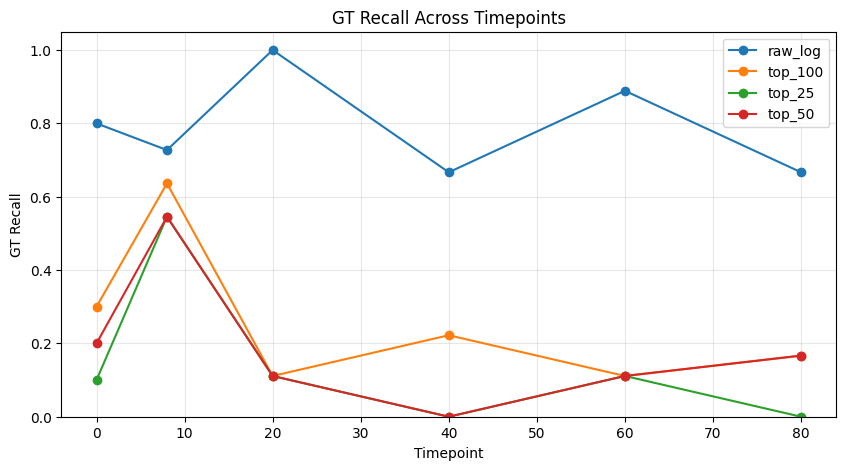

In [16]:
plt.figure(figsize=(10, 5))

for detector_name, group in multi_time_results_df.groupby("detector"):
    plt.plot(group["t"], group["gt_recall"], marker="o", label=detector_name)

plt.title("GT Recall Across Timepoints")
plt.xlabel("Timepoint")
plt.ylabel("GT Recall")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

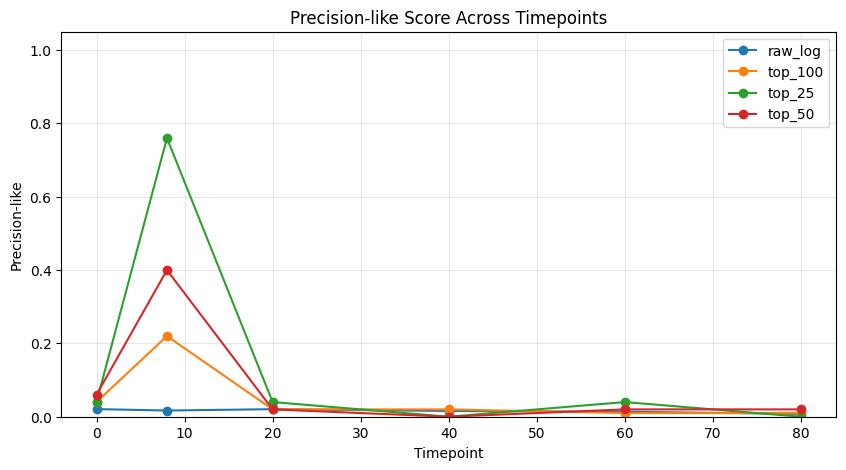

In [17]:
plt.figure(figsize=(10, 5))

for detector_name, group in multi_time_results_df.groupby("detector"):
    plt.plot(group["t"], group["pred_precision_like"], marker="o", label=detector_name)

plt.title("Precision-like Score Across Timepoints")
plt.xlabel("Timepoint")
plt.ylabel("Precision-like")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 5 — Visualize One Held-Out Timepoint

I will visualize a held-out timepoint to see whether the filtered detector still concentrates predictions around GT centroids outside the training frame.

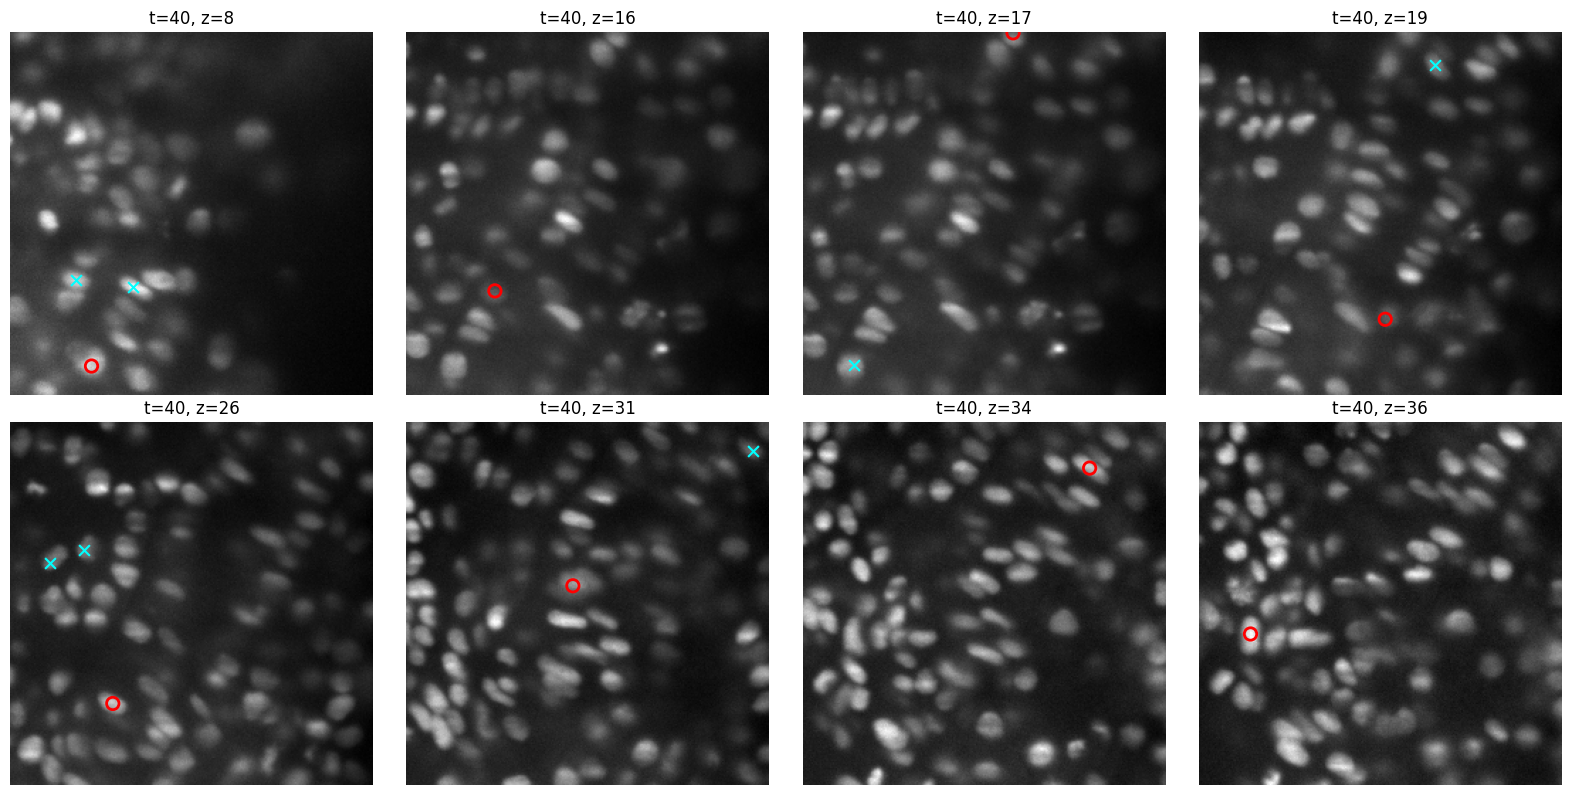

In [18]:
t_vis = 40
top_k_vis = 50

ranked_vis = ranked_by_time[t_vis]
gt_vis = gt_by_time[t_vis]
frame_vis = image[t_vis]

top_vis_df = ranked_vis.head(top_k_vis).copy()
gt_z_slices = sorted(gt_vis["z"].unique())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, z in zip(axes, gt_z_slices[:8]):
    slice_img = frame_vis[z]
    gt_slice = gt_vis[gt_vis["z"] == z]
    pred_slice = top_vis_df[top_vis_df["z"] == z]

    ax.imshow(slice_img, cmap="gray")

    # GT
    ax.scatter(gt_slice["x"], gt_slice["y"],
               facecolors="none", edgecolors="red", s=80, linewidths=2)

    # filtered predictions
    ax.scatter(pred_slice["x"], pred_slice["y"],
               c="cyan", marker="x", s=60)

    ax.set_title(f"t={t_vis}, z={z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
best_detector_avg = detector_avg_df.sort_values(
    ["gt_recall", "pred_precision_like"],
    ascending=[False, False]
).iloc[0]

best_detector_avg

gt_recall                 0.791582
pred_precision_like       0.015847
num_pred               1680.500000
Name: raw_log, dtype: float64

In [20]:
print("Best detector on average across tested timepoints:")
print(best_detector_avg)

Best detector on average across tested timepoints:
gt_recall                 0.791582
pred_precision_like       0.015847
num_pred               1680.500000
Name: raw_log, dtype: float64


# 📊 Results

I trained the candidate-ranking model on reference timepoint `t = 8` and applied it to multiple other timepoints from the same sample.

## Main result
The filtered detector did **not** generalize well across timepoints.

- At the training-like frame (`t = 8`), top-k filtering produced strong enrichment of GT-like detections.
- At many other timepoints, filtered detector recall dropped sharply.
- Raw LoG remained the best detector on average across timepoints because it preserved recall more consistently, despite having very poor precision-like behavior.

## Average best detector across tested timepoints
- **detector:** raw_log
- **average GT recall:** ~0.79
- **average precision-like:** ~0.016

# 🔍 Analysis

This experiment shows that the current candidate-ranking model is not yet learning a stable, time-invariant notion of a GT-like cell center.

## Main findings

### 1. The ranking model appears overfit to the reference frame
The detector performed best at or near the training timepoint (`t = 8`) and degraded substantially on other frames.

### 2. Raw LoG is noisy but robust
Raw LoG continued to recover many GT cells across timepoints, even though it produced many false positives.

### 3. The current training setup is too narrow
The ranking model was trained on only one timepoint, with a very small positive class. This likely caused it to learn frame-specific features rather than generalizable cell-center cues.

### 4. The unmatched class is ambiguous
Because the GT labels are sparse, unmatched detections are not guaranteed to be biologically false. This weakens the supervision signal for the classifier.

# 📝 What I Learned

Today I learned that:

- a candidate filter that works well on one frame may fail badly across time
- recall stability across time is an important benchmark, not just single-frame precision
- training on a single timepoint is not enough to build a robust filtered detector
- raw LoG is still a valuable baseline because it generalizes better than the current learned filter

# 🚀 Next Steps

## Chapter 12 — Train the Candidate Filter on Multiple Timepoints

The next step is to improve generalization by training the candidate-ranking model on multiple timepoints instead of only one.

Goals:
- collect candidate detections from several timepoints in the same sample
- combine them into one larger training table
- retrain the GT-like ranking model on this multi-timepoint dataset
- test whether filtered detector performance becomes more stable across time